<a href="https://colab.research.google.com/github/Shranya24/ai_ml/blob/main/linregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [137]:
import numpy as np


LINEAR REGRESSION

In [138]:
class Linear_Regression:
#initiating the parameters:
    def __init__(self,learning_rate,no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations


    def fit(self,X,Y):
        #number of traing examples and number of features
        self.m, self.n = X.shape
        #initiating the weight and bias with zeroes
        self.w= np.zeros(self.n)
        self.b= 0
        self.X =X
        self.Y=Y
        #implementing gradient descent
        for i in range(self.no_of_iterations):
            self.update_weights()


    def update_weights(self,):
        Y_prediction = self.predict(self.X)
        #calculate gradients
        dw = -(2*(self.X.T).dot(self.Y- Y_prediction))/self.m #T is transpose needed for the multiplication of matrix
        db = -2*np.sum(self.Y- Y_prediction)/self.m
        #updating the weights
        self.w= self.w - self.learning_rate*dw
        self.b= self.b- self.learning_rate*db


    def predict(self,X):
        return X.dot(self.w)+ self.b

using linear regression model for prediction

In [139]:
#importing the dependencies
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


loading the data


In [140]:
salary_data= pd.read_csv('/content/salary_data.csv')

In [141]:
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


splittting the features and target

In [142]:
X= salary_data.iloc[:,:-1]
Y= salary_data.iloc[:,1]

In [143]:
print(X)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [144]:
print(Y)

0      39343
1      46205
2      37731
3      43525
4      39891
5      56642
6      60150
7      54445
8      64445
9      57189
10     63218
11     55794
12     56957
13     57081
14     61111
15     67938
16     66029
17     83088
18     81363
19     93940
20     91738
21     98273
22    101302
23    113812
24    109431
25    105582
26    116969
27    112635
28    122391
29    121872
Name: Salary, dtype: int64


splitting the data into training and testing data

In [145]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size= 0.4, random_state=2)

training the linear regression model

In [146]:
model= Linear_Regression(learning_rate=0.02, no_of_iterations=1000)

In [147]:
model.fit(X_train,Y_train)

In [148]:
#printing the parametrs values(weight and bias)
print("weight= ", model.w[0])
print("bias= " ,model.b)

weight=  9690.903567595193
bias=  22521.447208551584


/tmp/ipykernel_10987/1776935973.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("weight= ", model.w[0])


y= 9534x+ 23735

prediction

In [149]:
test_data_prediction = model.predict(X_test)

In [150]:
print(test_data_prediction)

1      35119.621846
0      33181.441133
14     66130.513263
9      58377.790409
21     91326.862538
19     80666.868614
23    101986.856463
6      51594.157911
3      41903.254344
20     88419.591468
5      50625.067555
27    115554.121457
dtype: float64


comparing actual with predictions

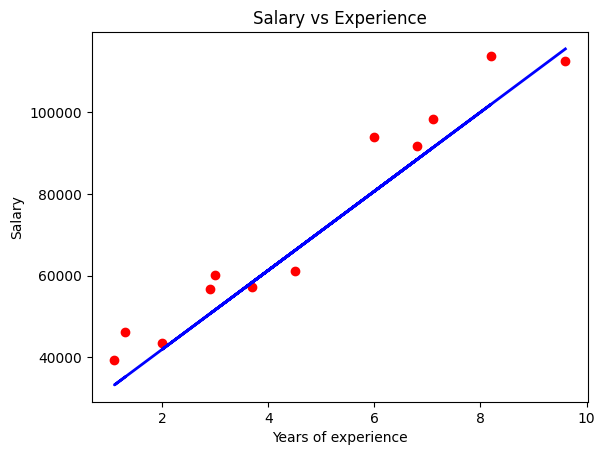

In [151]:
plt.scatter(X_test,Y_test,color= 'red')
plt.plot(X_test,test_data_prediction, color='blue',linewidth=2)
plt.xlabel("Years of experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.show()